In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector, SelectFromModel
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import statsmodels.api as sm
from matplotlib import pyplot as plt
import numpy as np


## 1 Предобработка

In [2]:
data = fetch_openml(name="house_prices", as_frame=True)
house_data = data.data
target = data.target
display(house_data, target)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [3]:
house_data = house_data.select_dtypes(include="number")

index_to_keep = house_data.dropna().index
house_data = house_data.loc[index_to_keep]
target = target.loc[index_to_keep]
house_data.drop(columns=["Id"], inplace=True)

<Axes: >

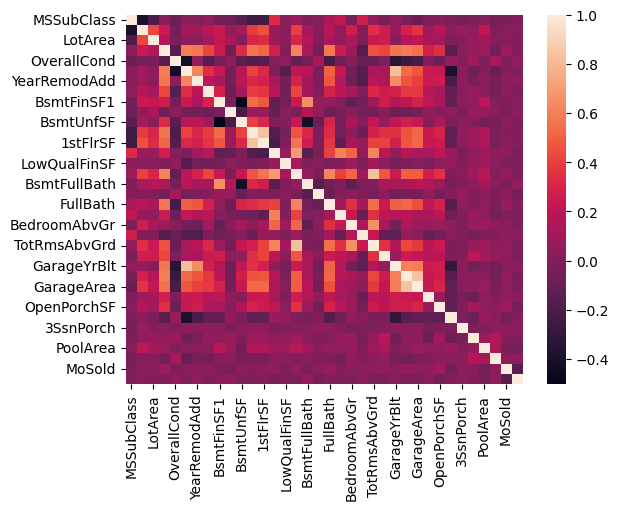

In [9]:
sns.heatmap(house_data.corr())

In [10]:
X = MinMaxScaler().fit_transform(house_data)

X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.3)

## 2 Построение моделей и оценка признаков

In [ ]:
# Построенрие регрессии и оценка параметров
X2 = sm.add_constant(X)
model_sm = sm.OLS(target, X2).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     135.7
Date:                Thu, 12 Dec 2024   Prob (F-statistic):               0.00
Time:                        13:34:41   Log-Likelihood:                -13358.
No. Observations:                1121   AIC:                         2.679e+04
Df Residuals:                    1086   BIC:                         2.696e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.012e+04   1.06e+04     -1.907      0.0

In [11]:
# Жадный алгоритм
lin_model = LinearRegression()
sfs = SequentialFeatureSelector(lin_model, n_features_to_select=25)
print(f"До: {X_train.shape}")
X_train_lin = sfs.fit_transform(X_train, y_train)
X_test_lin = sfs.transform(X_test)
print(f"После: {X_train_lin.shape}")

До: (784, 36)
После: (784, 25)


In [ ]:
shapes = []
# L1-регулиризация
for alpha in range(1, 52, 5):
  lasso_model = Lasso(alpha=alpha).fit(X, target)
  model = SelectFromModel(lasso_model, prefit=True)

  X_new = model.transform(X)

  shapes.append(36 - X_new.shape[1]) # type: ignore

print(shapes)

[1, 2, 2, 4, 3, 4, 5, 5, 8, 8, 8]


In [ ]:
# Случайный лес

rf = RandomForestRegressor().fit(X_train, y_train)

selector = SelectFromModel(rf, prefit=True, threshold=0.001)
X_train_rf = selector.transform(X_train)
X_test_rf = selector.transform(X_test)
print(f"До: {X_train.shape}")
print(f"После: {X_train_rf.shape}")

До: (784, 36)
После: (784, 29)


In [5]:
# Градиентный бустинг

gb = GradientBoostingRegressor().fit(X_train, y_train)

selector = SelectFromModel(gb, prefit=True, threshold=0.001)
X_train_gb = selector.transform(X_train)
X_test_gb = selector.transform(X_test)
print(f"До: {X_train.shape}")
print(f"После: {X_train_gb.shape}")

До: (784, 36)
После: (784, 26)


## 3 Визуализация

<ipython-input-13-c5ba7330ab91>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.barh(house_data.columns[sort_index], np.abs(importance[sort_index]), color=["red" if el > 0 else "blue" for el in importance[sort_index]])


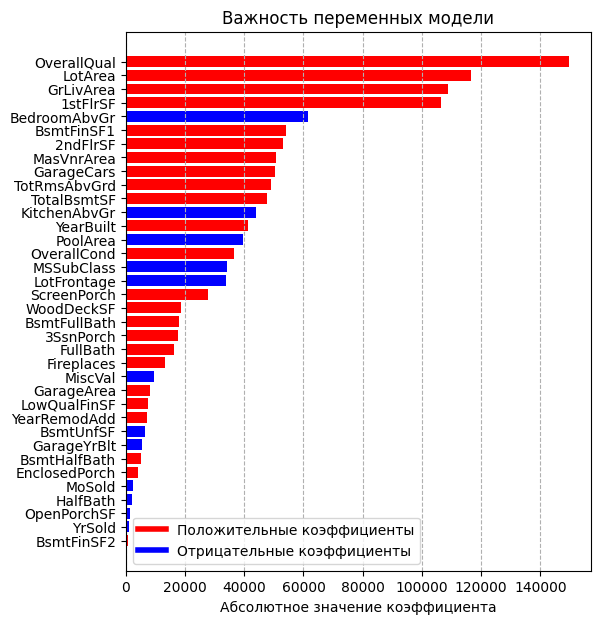

In [ ]:
# Визуализация коэффицентов

importance = model_sm.params[1:]
sort_index = np.argsort(np.abs(importance))
plt.figure(figsize=(6, 7))
plt.barh(house_data.columns[sort_index], np.abs(importance[sort_index]), color=["red" if el > 0 else "blue" for el in importance[sort_index]])
plt.xlabel("Размер коэффициента")
red_patch = plt.Line2D([0], [0], color='red', lw=4, label='Положительные коэффициенты')
blue_patch = plt.Line2D([0], [0], color='blue', lw=4, label='Отрицательные коэффициенты')
plt.legend(handles=[red_patch, blue_patch])

plt.xlabel('Абсолютное значение коэффициента')
plt.title('Важность переменных модели')
plt.grid(axis='x', linestyle='--')
plt.show()

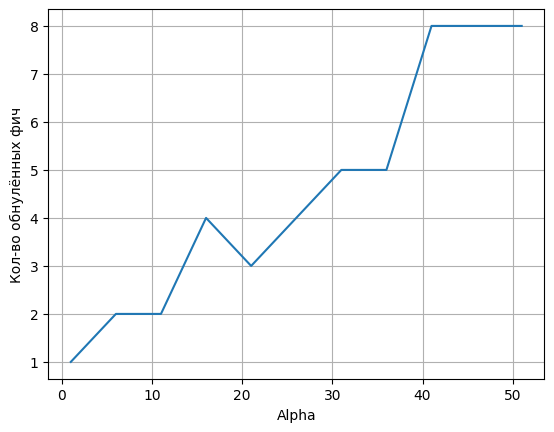

In [ ]:
#L1 визулизаци
plt.plot(np.arange(1, 52, 5), shapes)
plt.grid()
plt.xlabel("Alpha")
plt.ylabel("Кол-во обнулённых фич")
plt.show()

In [ ]:
# Random forest
importance = rf.feature_importances_
sort_index = np.argsort(np.abs(importance))
plt.figure(figsize=(6, 7))
plt.barh(house_data.columns[sort_index], np.abs(importance[sort_index]))
plt.xlabel("feature_importance")
plt.show()

## 4 СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ

In [ ]:
# Простая линейная регрессия
full_line = LinearRegression().fit(X_train, y_train)
new_line = LinearRegression().fit(X_train_lin, y_train)

print(f"MSE на всех признаках: {mean_squared_error(y_test, full_line.predict(X_test)): >20.2f}")
print(f"MSE на отобранных признаках: {mean_squared_error(y_test, new_line.predict(X_test_lin)): >14.2f}")

MSE на всех признаках:              1018147144.65
MSE на отобранных признаках:        1097517572.98


In [ ]:
# Случайный лес
new_rf = RandomForestRegressor().fit(X_train_rf, y_train)

print(f"MSE на всех признаках: {mean_squared_error(y_test, rf.predict(X_test)): >20.2f}")
print(f"MSE на отобранных признаках: {mean_squared_error(y_test, new_rf.predict(X_test_rf)): >14.2f}")

MSE на всех признаках:         748429781.03
MSE на отобранных признаках:   734664695.17


In [ ]:
# Градинтный бустинг
new_gb = GradientBoostingRegressor().fit(X_train_gb, y_train)

print(f"MSE на всех признаках: {mean_squared_error(y_test, gb.predict(X_test)): >20.2f}")
print(f"MSE на отобранных признаках: {mean_squared_error(y_test, new_gb.predict(X_test_gb)): >14.2f}")

MSE на всех признаках:         718938813.47
MSE на отобранных признаках:   701092835.09


##5 СНИЖЕНИЕ РАЗМЕРНОСТИ И ВИЗУАЛИЗАЦИЯ ДАННЫХ

In [8]:
#PCA
reductor = PCA(n_components=0.96)
X_train_pca = reductor.fit_transform(X_train)
X_test_pca = reductor.transform(X_test)
print(f"До: {X_train.shape}")
print(f"После: {X_train_pca.shape}")

pca_gb = GradientBoostingRegressor().fit(X_train_pca, y_train)

print(f"MSE на всех признаках: {mean_squared_error(y_test, gb.predict(X_test)): >26.2f}")
print(f"MSE на преобразованнных признаках: {mean_squared_error(y_test, pca_gb.predict(X_test_pca)): >14.2f}")

До: (784, 36)
После: (784, 23)
MSE на всех признаках:               619800934.79
MSE на преобразованнных признаках:  1093126624.11


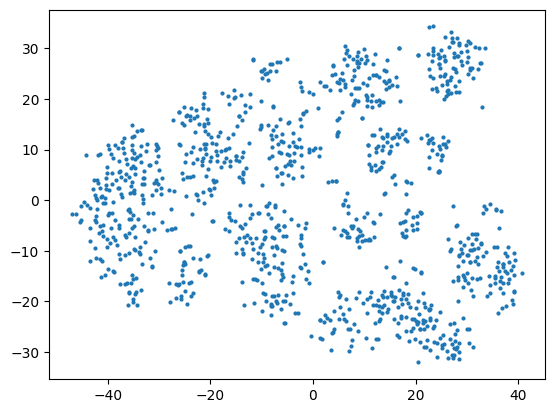

In [ ]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=4)
plt.show()